# 🎓 Pass or Fail Prediction Using Machine Learning

This notebook demonstrates a complete machine learning pipeline to predict whether a student will **Pass** or **Fail** based on:
- **StudyHours** — daily hours spent studying
- **PreviousResult** — score in previous exam
- **Attendance** — class attendance percentage

**Target:** `Result` — 1 = Pass (FinalMarks ≥ 60), 0 = Fail

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)

sns.set_theme(style='whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Data Loading & Exploration

In [2]:
df = pd.read_csv('data/student_data.csv')
print('Dataset shape:', df.shape)

Dataset shape: (600, 4)


In [3]:
df.head()

,StudyHours,PreviousResult,Attendance,FinalMarks
0,4.5,16.9,75.8,42.2
1,11.4,27.9,2.5,48.3
2,8.8,17.7,2.2,53.7
3,7.2,8.9,32.4,39.6
4,1.9,12.1,48.9,26.8


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   StudyHours      600 non-null    float64
 1   PreviousResult  600 non-null    float64
 2   Attendance      600 non-null    float64
 3   FinalMarks      600 non-null    float64
dtypes: float64(4)
memory usage: 18.9 KB


In [5]:
df.describe()

,StudyHours,PreviousResult,Attendance,FinalMarks
count,600.000000,600.000000,600.000000,600.000000
mean,6.034000,49.528333,49.430833,63.219833
std,3.580887,29.096330,29.081465,18.816055
min,0.100000,0.500000,0.500000,13.600000
25%,2.900000,23.275000,23.475000,49.800000
50%,6.200000,50.000000,49.450000,64.300000
75%,9.125000,74.800000,73.225000,76.525000
max,12.000000,99.800000,99.900000,100.000000


## 3. Data Cleaning & Preprocessing

Check for missing values, invalid entries, and outliers.

In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
StudyHours        0
PreviousResult    0
Attendance        0
FinalMarks        0
dtype: int64


In [7]:
# Handle missing values by imputing with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)
print('Missing values after imputation:', df.isnull().sum().sum())

Missing values after imputation: 0


In [8]:
# Check for and handle invalid/negative values
numeric_cols = ['StudyHours', 'PreviousResult', 'Attendance', 'FinalMarks']
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'{col}: {neg_count} negative values found — clipping to 0')
        df[col] = df[col].clip(lower=0)
print('Negative value check complete.')

Negative value check complete.


In [9]:
# Check for outliers using IQR method (informational)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: {outliers} outliers detected')

StudyHours: 0 outliers detected
PreviousResult: 0 outliers detected
Attendance: 0 outliers detected
FinalMarks: 0 outliers detected


## 4. Add Pass/Fail Label Column

Create the binary target column: **1 = Pass** (FinalMarks ≥ 60), **0 = Fail**.

In [10]:
df['Result'] = df['FinalMarks'].apply(lambda x: 1 if x >= 60 else 0)
print('Pass/Fail distribution:')
print(df['Result'].value_counts())
print(f"\nPass rate: {df['Result'].mean() * 100:.1f}%")

Pass/Fail distribution:
Result
1    347
0    253
Name: count, dtype: int64

Pass rate: 57.8%


## 5. Data Visualizations

Explore the data visually to understand distributions and relationships.

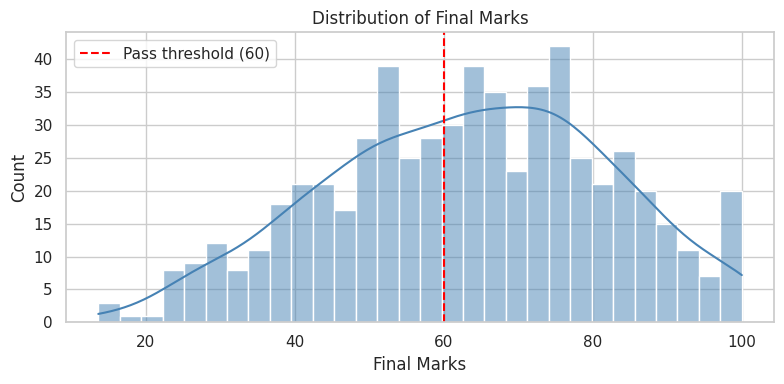

In [11]:
# 5.1 Distribution of Final Marks
plt.figure(figsize=(8, 4))
sns.histplot(df['FinalMarks'], kde=True, bins=30, color='steelblue')
plt.axvline(60, color='red', linestyle='--', label='Pass threshold (60)')
plt.title('Distribution of Final Marks')
plt.xlabel('Final Marks')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

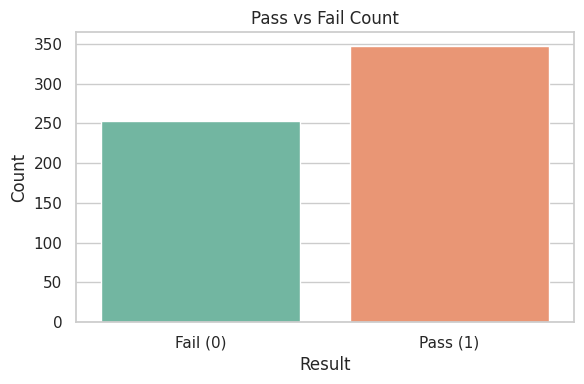

In [12]:
# 5.2 Pass vs Fail Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Result', data=df, palette='Set2')
plt.xticks([0, 1], ['Fail (0)', 'Pass (1)'])
plt.title('Pass vs Fail Count')
plt.xlabel('Result')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

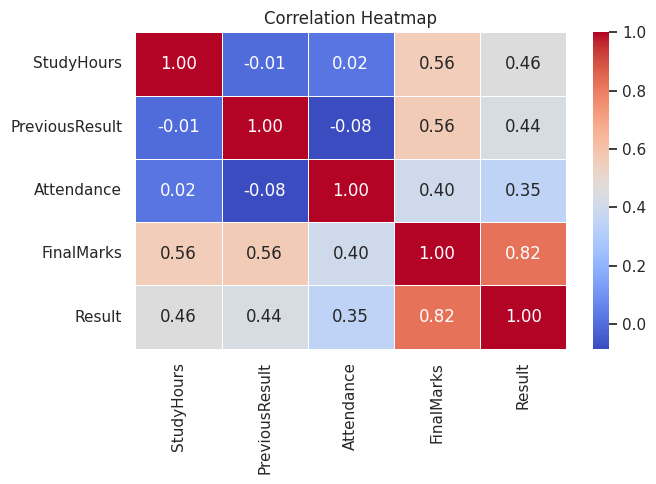

In [13]:
# 5.3 Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

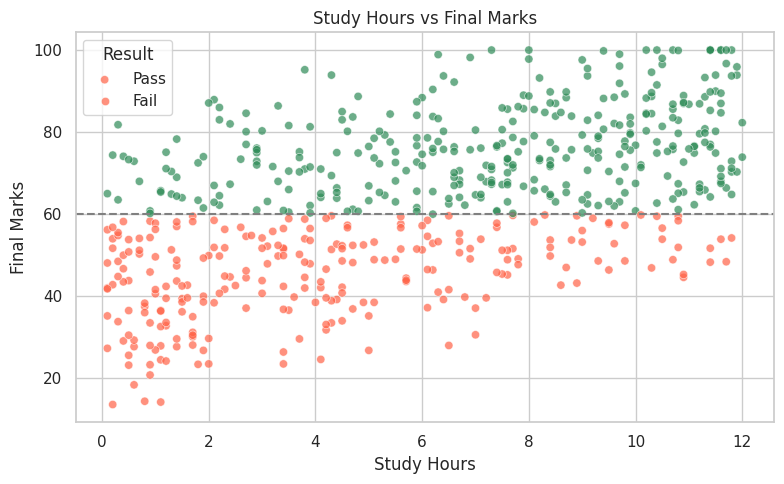

In [14]:
# 5.4 Study Hours vs Final Marks (colored by Result)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='StudyHours', y='FinalMarks', hue='Result',
                data=df, palette={0: 'tomato', 1: 'seagreen'}, alpha=0.7)
plt.axhline(60, color='gray', linestyle='--', label='Pass threshold')
plt.title('Study Hours vs Final Marks')
plt.xlabel('Study Hours')
plt.ylabel('Final Marks')
plt.legend(title='Result', labels=['Pass', 'Fail'])
plt.tight_layout()
plt.show()

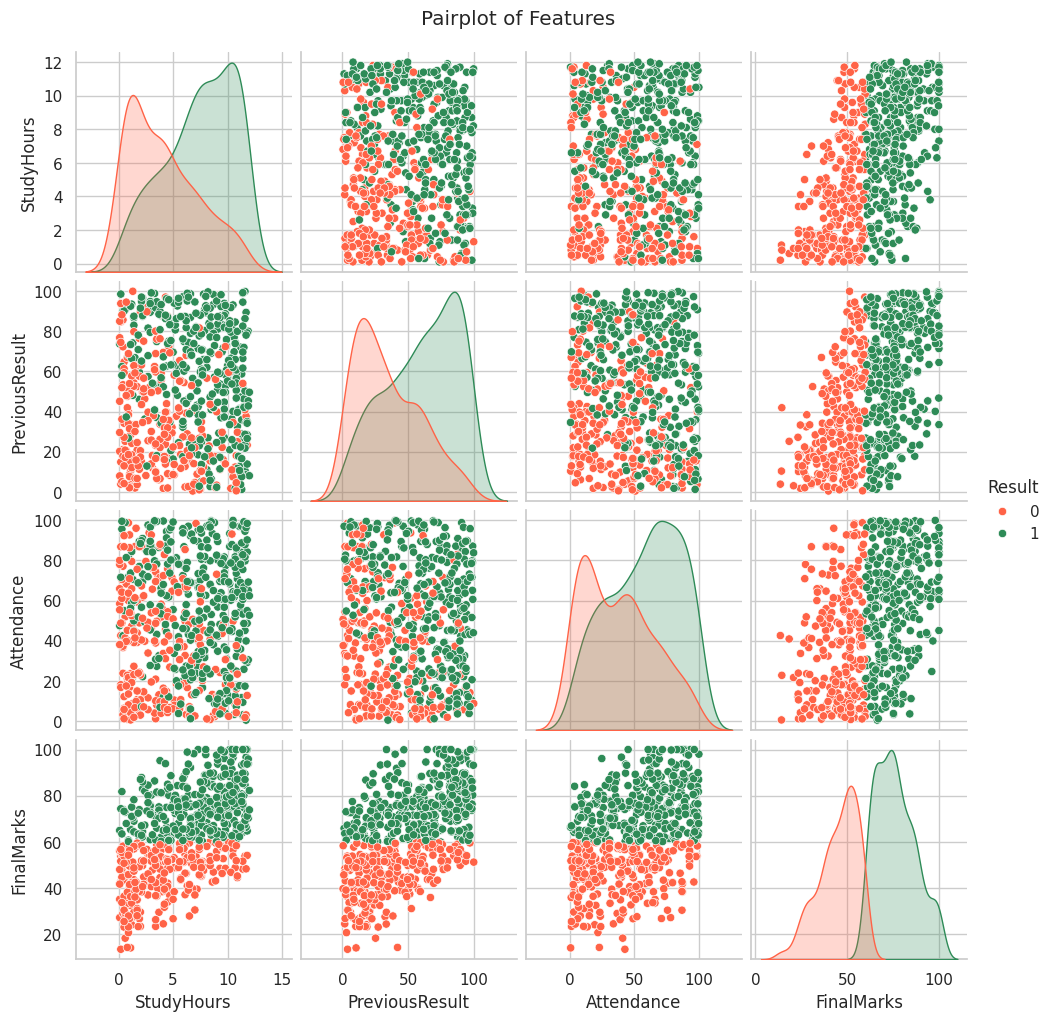

In [15]:
# 5.5 Pairplot of all features
sns.pairplot(df[['StudyHours', 'PreviousResult', 'Attendance', 'FinalMarks', 'Result']],
             hue='Result', palette={0: 'tomato', 1: 'seagreen'}, diag_kind='kde')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

## 6. Feature Selection & Train-Test Split

- **Features (X):** StudyHours, PreviousResult, Attendance
- **Target (y):** Result (1 = Pass, 0 = Fail)
- **Split:** 80% train / 20% test

In [16]:
X = df[['StudyHours', 'PreviousResult', 'Attendance']]
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size:     {X_test.shape[0]}')

Training set size: 480
Test set size:     120


## 7. Feature Scaling

Standardize features to zero mean and unit variance.

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X)  # Full dataset scaled (for cross-validation)
print('Feature scaling complete.')

Feature scaling complete.


## 8. Train & Compare Multiple Classification Models

Train five classifiers and compare their accuracy on the test set.

In [18]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    accuracy = model.score(X_test_scaled, y_test)
    results[name] = accuracy
    print(f'{name:25s}: Accuracy = {accuracy * 100:.2f}%')

Logistic Regression      : Accuracy = 89.17%
Decision Tree            : Accuracy = 75.00%
Random Forest            : Accuracy = 84.17%
SVM                      : Accuracy = 86.67%
KNN                      : Accuracy = 84.17%


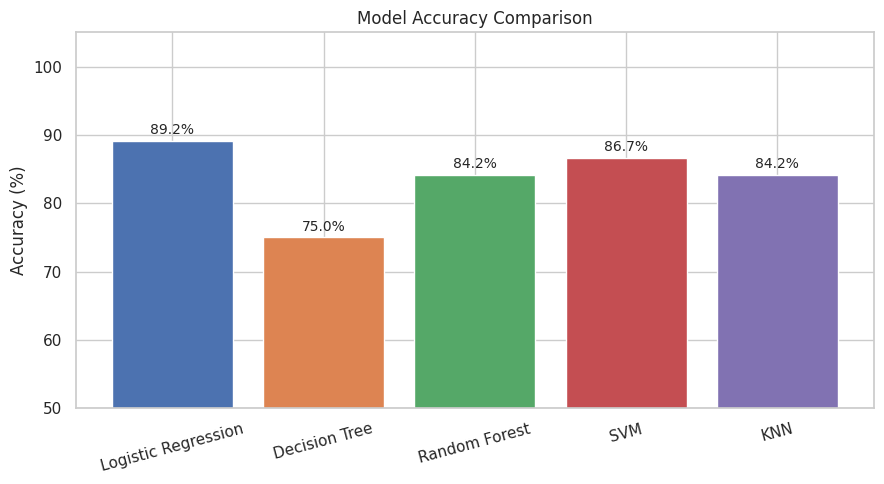

In [19]:
# Bar chart comparing model accuracies
plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), [v * 100 for v in results.values()],
               color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
plt.ylim(50, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. Evaluate the Best Model

Select the model with the highest accuracy and evaluate it with full metrics.

In [20]:
best_name = max(results, key=results.get)
best_model = models[best_name]
print(f'Best model: {best_name} ({results[best_name]*100:.2f}%)')

y_pred = best_model.predict(X_test_scaled)

print('\n--- Evaluation Metrics ---')
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

Best model: Logistic Regression (89.17%)

--- Evaluation Metrics ---
Accuracy:  0.8917
Precision: 0.8841
Recall:    0.9242
F1 Score:  0.9037

Confusion Matrix:
[[46  8]
 [ 5 61]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.90      0.85      0.88        54
        Pass       0.88      0.92      0.90        66

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120



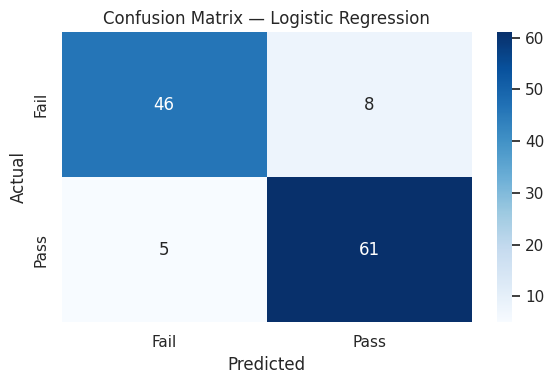

In [21]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 10. Cross-Validation

Use 5-fold cross-validation on the full dataset to verify model generalization.

In [22]:
scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print(f'Cross-Validation Scores: {scores}')
print(f'Mean Accuracy: {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)')

Cross-Validation Scores: [0.875      0.85       0.84166667 0.89166667 0.86666667]
Mean Accuracy: 86.50% (+/- 1.78%)


## 11. Predict for a New Student

Enter student data to get a Pass/Fail prediction.

In [23]:
# Example prediction (replace input() calls with fixed values for batch execution)
study_hours     = 8.0   # float(input('Enter Study Hours (0-12): '))
previous_result = 75.0  # float(input('Enter Previous Result (0-100): '))
attendance      = 85.0  # float(input('Enter Attendance % (0-100): '))

user_data = scaler.transform([[study_hours, previous_result, attendance]])
prediction = best_model.predict(user_data)

print(f'Study Hours:     {study_hours}')
print(f'Previous Result: {previous_result}')
print(f'Attendance:      {attendance}%')
print()
if prediction[0] == 1:
    print('🎉 Prediction: PASS')
else:
    print('😞 Prediction: FAIL')

Study Hours:     8.0
Previous Result: 75.0
Attendance:      85.0%

🎉 Prediction: PASS
